# Import required library

In [10]:
import epi_utils as eu
import pandas as pd
import pyranges as pr
import glob
from tqdm.auto import tqdm

In [2]:
chrom_list = ['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22', 'chrMT', 'chrUn']

# Splitting Histone Data

In [3]:
# Load histone file
histone_df = eu.load_histone_files()
display(histone_df.head())

,chrom,chromStart,chromEnd,name,length,type
0,chr10,119808,119954,chr10_173,146,h3k4me3
1,chr10,119956,120102,chr10_174,146,h3k4me3
2,chr10,122100,122246,chr10_185,146,h3k4me3
3,chr10,122308,122454,chr10_186,146,h3k4me3
4,chr10,180346,180492,chr10_489,146,h3k4me3


In [5]:
histone_chrom = histone_df['chrom'].unique()
display(histone_chrom)

array(['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22'], dtype=object)

In [ ]:
pd.DataFrame(histone_df['chrom'].unique()).to_csv("dataset/histone_chromosome.csv", index=False, header=False)

In [ ]:
for chrom in histone_chrom:
    df = histone_df[histone_df['chrom'] == chrom]
    print(f"Processing {chrom} with {len(df.index)} data")
    df.to_csv("dataset/histone/" + chr + ".csv", index=False)

# Splitting NCBI RefSeq Data

In [6]:
hg19ncbiRefSeq_df = eu.load_ncbiRefSeq()

In [7]:
display(hg19ncbiRefSeq_df.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chrMT,ncbiRefSeq.2021-05-17,transcript,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,NaN,NaN,16023
1,chrMT,ncbiRefSeq.2021-05-17,exon,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,1,rna-TRNP.1,16023
2,chrMT,ncbiRefSeq.2021-05-17,transcript,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,NaN,NaN,15887
3,chrMT,ncbiRefSeq.2021-05-17,exon,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,1,rna-TRNT.1,15887
4,chrMT,ncbiRefSeq.2021-05-17,transcript,14746,15887,.,+,.,CYTB,YP_003024038.1,CYTB,NaN,NaN,14746


In [8]:
hg19ncbiRefSeq_chrom = hg19ncbiRefSeq_df["Chromosome"].unique()

## Splitting into each `Chromosome`

In [ ]:
print(f"Splitting into {len(hg19ncbiRefSeq_chrom)} files.")

num_file = 1

for chrom in hg19ncbiRefSeq_chrom:
    df = hg19ncbiRefSeq_df[hg19ncbiRefSeq_df['Chromosome'] == chrom]
    print(f"File {num_file}: Processing {chrom} with {len(df.index)} data")
    df.to_csv(f"dataset/ncbiRefSeq/raw/{chrom}.csv", index=False)
    num_file+=1

## Combining similar `Chromosome`

In [9]:
# Flatten the glob result
def flatten_concatenation(matrix):
    flat_list = []
    for row in matrix:
        flat_list += row
    return flat_list

In [11]:
for chrom in tqdm(histone_chrom):
    print(f"Processing chromosome: {chrom}")
    file_list = []
    file_list.append(glob.glob(f"dataset/ncbiRefSeq/raw/{chrom}.csv"))
    file_list.append(glob.glob(f"dataset/ncbiRefSeq/raw/{chrom}_*.csv"))
    flat_file_list = flatten_concatenation(file_list)

    data = []
    for filename in flat_file_list:
        print(f"Processing file: {filename}")
        df = pd.read_csv(filename)
        data.append(df)

    df_out = pd.concat(data, axis=0, ignore_index=False)
    df_out.to_csv(f"dataset/ncbiRefSeq/merged/{chrom}.csv", index=False)

print("Splitting ncbiRefSeq FINISHED!")

  0%|          | 0/24 [00:00<?, ?it/s]

Processing chromosome: chr10
Processing file: dataset/ncbiRefSeq/raw/chr10.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383543_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383545_alt.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383546_alt.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl877873_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591181_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591182_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591183_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh636060_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh806580_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_kb663606_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_ke332501_fix.csv
Processing chromosome: chr11
Processing file: dataset/ncbiRefSeq/raw/chr11.csv
Processing file: dataset/ncbiRefSeq/raw\chr11_gl582973_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr11_gl949744_fix.csv
Processing file: datase

In [12]:
# Copying 'chrMT'
import shutil

shutil.copy2('dataset/ncbiRefSeq/raw/chrMT.csv', 'dataset/ncbiRefSeq/merged/chrMT.csv')

'dataset/ncbiRefSeq/merged/chrMT.csv'

In [13]:
# Appending 'chrUn'

file_list = []
file_list.append(glob.glob("dataset/ncbiRefSeq/raw/chrUn*.csv"))
flat_file_list = flatten_concatenation(file_list)

data = []
for filename in flat_file_list:
    print(f"Processing file: {filename}")
    df = pd.read_csv(filename)
    data.append(df)

df_out = pd.concat(data, axis=0, ignore_index=False)
df_out.to_csv(f"dataset/ncbiRefSeq/merged/chrUn.csv", index=False)

Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000211.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000212.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000213.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000215.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000218.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000219.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000220.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000224.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000228.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000229.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000230.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000231.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000235.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000236.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000241.csv


# Counting Histone in TSS

In [14]:
# Counting chrY
chrom = 'chrY'

histone_chr_df = pd.read_csv(f"dataset/histone/{chrom}.csv")
ncbiRefSeq_chr_df = pd.read_csv(f"dataset/ncbiRefSeq/merged/{chrom}.csv")

display(histone_chr_df.head())
print(histone_chr_df.shape)
display(ncbiRefSeq_chr_df.head())
print(ncbiRefSeq_chr_df.shape)

,chrom,chromStart,chromEnd,name,length,type
0,chrY,2649505,2649651,chrY_7,146,h3k4me3
1,chrY,2655498,2655644,chrY_28,146,h3k4me3
2,chrY,2655648,2655794,chrY_29,146,h3k4me3
3,chrY,2664998,2665144,chrY_59,146,h3k4me3
4,chrY,2665253,2665399,chrY_60,146,h3k4me3


(463, 6)


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chrY,ncbiRefSeq.2021-05-17,transcript,59358328,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,NaN,NaN,59360854
1,chrY,ncbiRefSeq.2021-05-17,exon,59358328,59359508,.,-,.,DDX11L16,NR_110561.1,DDX11L16,3.0,NR_110561.1.3,59359508
2,chrY,ncbiRefSeq.2021-05-17,exon,59360006,59360115,.,-,.,DDX11L16,NR_110561.1,DDX11L16,2.0,NR_110561.1.2,59360115
3,chrY,ncbiRefSeq.2021-05-17,exon,59360500,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,1.0,NR_110561.1.1,59360854
4,chrY,ncbiRefSeq.2021-05-17,transcript,59354328,59358341,.,+,.,WASH6P,WASH6P,WASH6P,NaN,NaN,59354328


(8468, 14)


In [18]:
tqdm.pandas()

In [19]:
# Counting Histone
ncbiRefSeq_chr_df.loc[:, "histone_count"] = ncbiRefSeq_chr_df.progress_apply(\
                            lambda row: eu.count_histone(histone_chr_df, row), axis=1)

  0%|          | 0/8468 [00:00<?, ?it/s]

In [20]:
display(ncbiRefSeq_chr_df.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chrY,ncbiRefSeq.2021-05-17,transcript,59358328,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,NaN,NaN,59360854,0
1,chrY,ncbiRefSeq.2021-05-17,exon,59358328,59359508,.,-,.,DDX11L16,NR_110561.1,DDX11L16,3.0,NR_110561.1.3,59359508,0
2,chrY,ncbiRefSeq.2021-05-17,exon,59360006,59360115,.,-,.,DDX11L16,NR_110561.1,DDX11L16,2.0,NR_110561.1.2,59360115,0
3,chrY,ncbiRefSeq.2021-05-17,exon,59360500,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,1.0,NR_110561.1.1,59360854,0
4,chrY,ncbiRefSeq.2021-05-17,transcript,59354328,59358341,.,+,.,WASH6P,WASH6P,WASH6P,NaN,NaN,59354328,0


In [21]:
ncbiRefSeq_chr_df.to_csv(f"dataset/histone_count/{chrom}.csv", index=False)

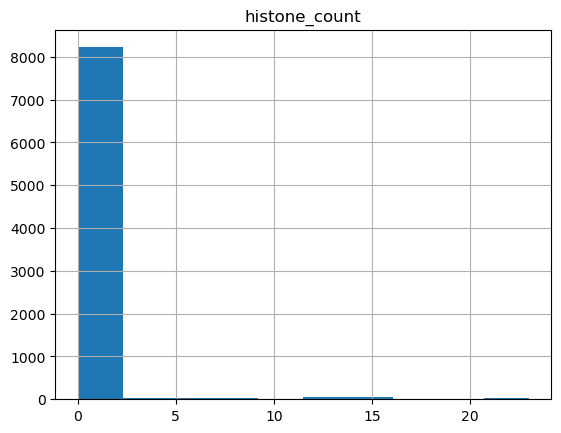

In [22]:
ax = ncbiRefSeq_chr_df.hist(column=["histone_count"])

In [23]:
histone_path = "dataset/histone/"
ncbiRefSeq_path = "dataset/ncbiRefSeq/merged/"
output_path = "dataset/histone_count/"

In [24]:
# chrUn and chrMT histone count should be 0

chrom = 'chrMT'

# Reading file
ncbiRefSeq_chr_df = pd.read_csv(f"{ncbiRefSeq_path}{chrom}.csv")

# Histone count = 0
ncbiRefSeq_chr_df.loc[:, "histone_count"] = 0
display(ncbiRefSeq_chr_df.head())

# Saving the result
ncbiRefSeq_chr_df.to_csv(f"{output_path}{chrom}.csv", index=False)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chrMT,ncbiRefSeq.2021-05-17,transcript,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,NaN,NaN,16023,0
1,chrMT,ncbiRefSeq.2021-05-17,exon,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,1.0,rna-TRNP.1,16023,0
2,chrMT,ncbiRefSeq.2021-05-17,transcript,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,NaN,NaN,15887,0
3,chrMT,ncbiRefSeq.2021-05-17,exon,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,1.0,rna-TRNT.1,15887,0
4,chrMT,ncbiRefSeq.2021-05-17,transcript,14746,15887,.,+,.,CYTB,YP_003024038.1,CYTB,NaN,NaN,14746,0


In [26]:
# Run the counting_histone.py to get the result
# Getting all the results back to dataframe

file_list = []
file_list.append(glob.glob(f"{output_path}*.csv"))
flat_file_list = flatten_concatenation(file_list)
print(flat_file_list)

['dataset/histone_count\\chr1.csv', 'dataset/histone_count\\chr10.csv', 'dataset/histone_count\\chr11.csv', 'dataset/histone_count\\chr12.csv', 'dataset/histone_count\\chr13.csv', 'dataset/histone_count\\chr14.csv', 'dataset/histone_count\\chr15.csv', 'dataset/histone_count\\chr16.csv', 'dataset/histone_count\\chr17.csv', 'dataset/histone_count\\chr18.csv', 'dataset/histone_count\\chr19.csv', 'dataset/histone_count\\chr2.csv', 'dataset/histone_count\\chr20.csv', 'dataset/histone_count\\chr21.csv', 'dataset/histone_count\\chr22.csv', 'dataset/histone_count\\chr3.csv', 'dataset/histone_count\\chr4.csv', 'dataset/histone_count\\chr5.csv', 'dataset/histone_count\\chr6.csv', 'dataset/histone_count\\chr7.csv', 'dataset/histone_count\\chr8.csv', 'dataset/histone_count\\chr9.csv', 'dataset/histone_count\\chrMT.csv', 'dataset/histone_count\\chrUn.csv', 'dataset/histone_count\\chrX.csv', 'dataset/histone_count\\chrY.csv']


In [28]:
data = []
for filename in tqdm(flat_file_list):
    df = pd.read_csv(filename)
    data.append(df)

df_out = pd.concat(data, axis=0, ignore_index=False)
df_out.to_csv(f"{output_path}histone_count.csv", index=False)

  0%|          | 0/26 [00:00<?, ?it/s]

In [31]:
display(df_out.head())
display(df_out.shape)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769,0
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,0
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992,0
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,13


(2093542, 15)

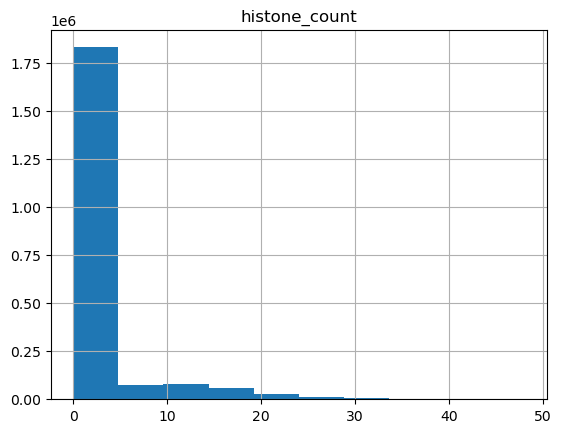

In [33]:
ax = df_out.hist(column=["histone_count"])

In [37]:
# Check the frequency of each histone count
df_out.groupby(['histone_count']).size().reset_index(name='counts')

,histone_count,counts
0,0,1649162
1,1,109795
2,2,33359
3,3,22439
4,4,18132
5,5,15168
6,6,15575
7,7,13560
8,8,14796
9,9,16699


# Splitting HepG2 data

## Loading and Preparing the Data

In [38]:
# Loading HepG2 data
hepg2_exp = pd.read_csv("dataset/GSM3718064_HepG2_exp.txt", sep="\t")

In [39]:
# Splitting chromosome name and the position
hepg2_exp[["chrom", "chromPos"]] = hepg2_exp["locus"].str.split(':', expand=True)
display(hepg2_exp.head())

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900


In [40]:
# Splitting start and end position
hepg2_exp[["chromStart", "chromEnd"]] = hepg2_exp["chromPos"].str.split('-', expand=True)
display(hepg2_exp.head())

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900


In [41]:
# Correcting the Data Types
hepg2_exp = hepg2_exp.astype({'chromStart': 'int32', 'chromEnd': 'int32'})

In [42]:
# Find the gene's length
hepg2_exp["gene_length"] = hepg2_exp["chromEnd"] - hepg2_exp["chromStart"]
display(hepg2_exp)

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008,918
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581,4690
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597,939
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889,33304
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900,3637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30027,XLOC_030028,XLOC_030028,-,chrY:13319431-13324829,hepg2_hr2,hepg2_hr3,OK,0.337879,0.457897,0.438516,1.137930,0.25685,0.999565,no,chrY,13319431-13324829,13319431,13324829,5398
30028,XLOC_030029,XLOC_030029,-,chrY:13325034-13326120,hepg2_hr2,hepg2_hr3,NOTEST,0.396888,0.357658,-0.150148,0.000000,1.00000,1.000000,no,chrY,13325034-13326120,13325034,13326120,1086
30029,XLOC_030030,XLOC_030030,-,chrY:13331089-13332358,hepg2_hr2,hepg2_hr3,OK,0.477227,0.127331,-1.906090,-1.861920,0.12490,0.999565,no,chrY,13331089-13332358,13331089,13332358,1269
30030,XLOC_030031,XLOC_030031,-,chrY:15053270-15053343,hepg2_hr2,hepg2_hr3,OK,123998.000000,71768.700000,-0.788894,-2.116040,0.04075,0.999565,no,chrY,15053270-15053343,15053270,15053343,73


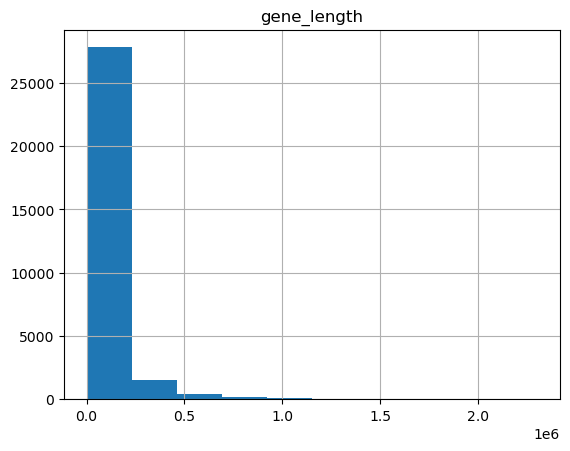

In [43]:
# Find the gene length distribution
ax = hepg2_exp.hist(column=["gene_length"])

In [44]:
# Find the frequency of gene length
hepg2_exp.groupby(['gene_length']).size().reset_index(name='counts')

,gene_length,counts
0,30,1
1,33,1
2,34,1
3,35,1
4,44,1
...,...,...
17968,2071499,3
17969,2173363,1
17970,2220389,1
17971,2298478,1


In [45]:
hepg2_exp.groupby(['gene_length'])['gene_length'].size().reset_index(name='counts').to_csv("dataset/HepG2/gene_length.csv", index=False)

## Splitting into each Chromosome

In [ ]:
# Find the unique chromosome name
pd.DataFrame(hepg2_exp["chrom"].unique(), columns=["chrom"]).to_csv("dataset/HepG2_Chromosome.csv", index=False, header=False)
hepg2_exp_chrom = hepg2_exp["chrom"].unique()
print(hepg2_exp_chrom)

In [ ]:
print(f"Splitting into {len(hepg2_exp_chrom)} files.")

num_file = 1

for chrom in hepg2_exp_chrom:
    df = hepg2_exp[hepg2_exp['chrom'] == chrom]
    print(f"File {num_file}: Processing {chrom} with {len(df.index)} data")
    df.to_csv(f"dataset/HepG2/raw/{chrom}.csv", index=False)
    num_file+=1

## Combining similar chromosome

In [ ]:
hepg2_exp_combined_chrom = ['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22', 'chrM', 'chrUn']

In [ ]:
for chrom in hepg2_exp_combined_chrom:
    print(f"Processing chromosome: {chrom}")
    file_list = []
    file_list.append(glob.glob(f"dataset/HepG2/raw/{chrom}.csv"))
    file_list.append(glob.glob(f"dataset/HepG2/raw/{chrom}_*.csv"))
    flat_file_list = flatten_concatenation(file_list)

    data = []
    for filename in flat_file_list:
        print(f"Processing file: {filename}")
        df = pd.read_csv(filename)
        data.append(df)

    df_out = pd.concat(data, axis=0, ignore_index=False)
    df_out.to_csv(f"dataset/HepG2/merged/{chrom}.csv", index=False)

print("Splitting HepG2 FINISHED!")

## Changing 'chrM' into 'chrMT'

In [ ]:
import os

hepg2_chrMT = pd.read_csv("dataset/HepG2/merged/chrM.csv")
hepg2_chrMT.head()

In [ ]:
hepg2_chrMT["chrom"] = "chrMT"
hepg2_chrMT.head()

In [ ]:
hepg2_chrMT.to_csv(f"dataset/HepG2/merged/chrMT.csv", index=False)

# Counting Gene Expression in the +/-2k from TSS

In [46]:
from tqdm.auto import tqdm
tqdm.pandas()

In [47]:
def count_gene(gene_df, row, threshold = 0.8, tss_length = 4000):
    tss = row["tss"]
    hist_df = gene_df.loc[  # Inside the +/- 2k from TSS
                             (((gene_df["chromStart"] >= tss - 2000) & (gene_df["chromEnd"] <= tss + 2000)) |
                             
                             # Intersect with -2k or +2 from TSS
                             (((gene_df["chromEnd"] - (tss - 2000))/tss_length).between(threshold, 1.0)) |
                             ((((tss + 2000) - gene_df["chromStart"])/tss_length).between(threshold, 1.0))) |
                             
                             # TSS inside the gene
                             ((tss + 2000 <= gene_df["chromEnd"]) & (tss - 2000 >= gene_df["chromStart"]))
                        ]
    
    return len(hist_df.index)

In [52]:
# Counting chr1
chrom = 'chr1'

gene_chr_df = pd.read_csv(f"dataset/HepG2/merged/{chrom}.csv")
ncbiRefSeq_chr_df = pd.read_csv(f"dataset/histone_count/{chrom}.csv")

display(gene_chr_df.head())
print(gene_chr_df.shape)
display(ncbiRefSeq_chr_df.head())
print(ncbiRefSeq_chr_df.shape)


,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008,918
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581,4690
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597,939
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889,33304
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900,3637


(2868, 19)


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769,0
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,0
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992,0
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,13


(193194, 15)


In [53]:
# Counting Gene
ncbiRefSeq_chr_df.loc[:, "gene_count"] = ncbiRefSeq_chr_df.progress_apply(\
                            lambda row: count_gene(gene_chr_df, row), axis=1)

  0%|          | 0/193194 [00:00<?, ?it/s]

In [51]:
display(ncbiRefSeq_chr_df.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,gene_count
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769,0
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,1
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992,1
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,0


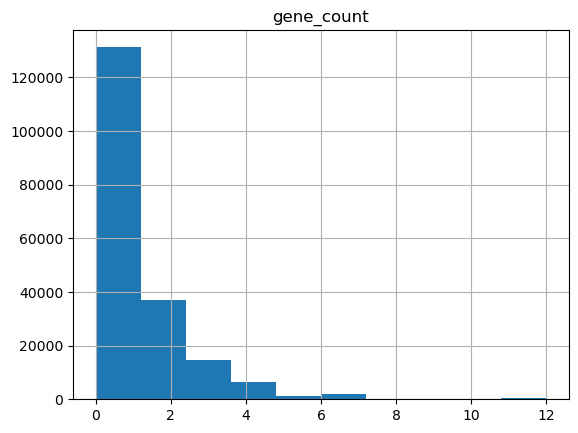

In [50]:
ax = ncbiRefSeq_chr_df.hist(column=["gene_count"])

In [54]:
ncbiRefSeq_chr_df.groupby(['gene_count']).size().reset_index(name='counts')

,gene_count,counts
0,0,37934
1,1,93274
2,2,37101
3,3,14778
4,4,6506
5,5,1040
6,6,895
7,7,1036
8,12,630


In [56]:
ncbiRefSeq_chr_df.groupby(['gene_count']).size().reset_index(name='counts').\
        to_csv(f"dataset/gene_count/gene_count_{chrom}.csv", index=False)

In [63]:
ncbiRefSeq_chr_df[(ncbiRefSeq_chr_df['gene_count'] >= 4) & (ncbiRefSeq_chr_df['histone_count'] > 20)]

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count,gene_count
34001,chr1,ncbiRefSeq.2021-05-17,transcript,186344969,186390507,.,+,.,ODR4,NM_001164246.2,ODR4,NaN,NaN,186344969,21,7
34002,chr1,ncbiRefSeq.2021-05-17,exon,186344969,186345106,.,+,.,ODR4,NM_001164246.2,ODR4,1.0,NM_001164246.2.1,186344969,21,7
34003,chr1,ncbiRefSeq.2021-05-17,5UTR,186344969,186345106,.,+,.,ODR4,NM_001164246.2,ODR4,1.0,NM_001164246.2.1,186344969,21,7
34032,chr1,ncbiRefSeq.2021-05-17,transcript,186344969,186390507,.,+,.,ODR4,NM_001164245.2,ODR4,NaN,NaN,186344969,21,7
34033,chr1,ncbiRefSeq.2021-05-17,exon,186344969,186345106,.,+,.,ODR4,NM_001164245.2,ODR4,1.0,NM_001164245.2.1,186344969,21,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191873,chr1_jh636053_fix,ncbiRefSeq.2021-05-17,CDS,894882,894934,.,+,2,NBPF26,NM_001351372.1,NBPF26,13.0,NM_001351372.1.13,894882,26,5
191874,chr1_jh636053_fix,ncbiRefSeq.2021-05-17,exon,895547,895720,.,+,.,NBPF26,NM_001351372.1,NBPF26,14.0,NM_001351372.1.14,895547,26,5
191875,chr1_jh636053_fix,ncbiRefSeq.2021-05-17,CDS,895547,895720,.,+,1,NBPF26,NM_001351372.1,NBPF26,14.0,NM_001351372.1.14,895547,26,5
191876,chr1_jh636053_fix,ncbiRefSeq.2021-05-17,exon,896439,896491,.,+,.,NBPF26,NM_001351372.1,NBPF26,15.0,NM_001351372.1.15,896439,23,5


In [66]:
ncbiRefSeq_chr_df.groupby(['histone_count', 'gene_count']).size().reset_index(name='counts')

,histone_count,gene_count,counts
0,0,0,20787
1,0,1,80860
2,0,2,31140
3,0,3,10907
4,0,4,4639
...,...,...,...
226,43,1,3
227,44,1,2
228,45,1,3
229,46,1,2


In [67]:
ncbiRefSeq_chr_df.groupby(['histone_count', 'gene_count']).size().reset_index(name='counts').\
    to_csv(f"dataset/histone_gene_count.csv", index=False)